In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

DATA_PATH = '../data/'
file_name = 'df_ml.csv'

df = pd.read_csv(DATA_PATH+file_name, sep=',')
df_copy = df.copy()
df_sim_real = df.iloc[-192:]
df = df.iloc[:-192]

df.shape

(16827, 31)

In [5]:
df.head(1)

,instant,season,year,month,hour,holiday,working_day,weather_sit,feeling_temp,hum,...,rolling_max_24,rolling_mean_168,rolling_median_168,rolling_std_168,rolling_min_168,rolling_max_168,lag_1,lag_6,lag_24,lag_168
0,169,1,0,1,7,0,0,2,0.1818,0.74,...,210.0,56.458333,49.0,51.220768,1.0,219.0,2.0,16.0,84.0,16.0


# Seleção das variáveis mais importantes

A partir da análise de importância das variáveis do modelo, foram identificadas as cinco features com maior contribuição para as previsões:

* `lag_1`
* `lag_168`
* `lag_24`
* `hour`
* `rolling_median_6`

As variáveis selecionadas representam diferentes aspectos temporais da demanda, como o comportamento mais recente, o padrão semanal, o padrão diário e horário.

Apesar da alta importância dessas features, essa medida deve ser interpretada com cautela, pois a importância das variáveis não indica causalidade e pode ser influenciada por correlações e pela interação entre as features utilizadas pelo modelo.

Essa análise será utilizada como referência para avaliar uma versão mais enxuta do modelo e verificar se é possível manter um desempenho semelhante com um conjunto reduzido de variáveis.


In [6]:
df_ml = df[['instant', 'working_day', 'feeling_temp', 'lag_1', 'lag_168', 'lag_24', 'hour', 'rolling_median_6', 'cnt']]
df_ml.head()

,instant,lag_1,lag_168,lag_24,hour,rolling_median_6,cnt
0,169,2.0,16.0,84.0,7,6.0,9
1,170,9.0,40.0,210.0,8,6.0,15
2,171,15.0,32.0,134.0,9,6.0,20
3,172,20.0,13.0,63.0,10,7.0,61
4,173,61.0,1.0,67.0,11,12.0,62


# Separação dos dados

In [28]:
TARGET_COLUMN = 'cnt'
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5, test_size=24)

X = df_ml.drop(columns=[TARGET_COLUMN])
y = df_ml[TARGET_COLUMN]

splits = list(tscv.split(X))

# Redução do overfitting

Após a remoção de variáveis com menor contribuição para o modelo, foi realizada uma nova avaliação.

Os resultados mostram uma redução da diferença entre as métricas de treino e validação. O R² médio passou a apresentar valores muito próximos entre os dois conjuntos, com aproximadamente 0,959 no treino e 0,957 na validação. O MAE também apresentou valores próximos, com 22,47 no treino e 22,91 na validação.

Esses resultados indicam uma redução dos sinais de overfitting observados anteriormente, sugerindo uma melhora na capacidade de generalização do modelo. Entretanto, houve aumento dos erros absolutos em relação à configuração anterior, indicando um trade-off entre ajuste aos dados de treinamento e desempenho preditivo.

In [30]:
from sklearn.base import clone

SEED = 42

def evaluate_train_validation(model, X):
    train_validation_metrics = []

    for fold, (train_index, test_index) in enumerate(splits, start=1):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model_fold = clone(model)
        model_fold.fit(X_train, y_train)

        y_train_pred = model_fold.predict(X_train)
        y_test_pred = model_fold.predict(X_test)

        train_validation_metrics.append({
            'Fold': fold,
            'Train MAE': mean_absolute_error(y_train, y_train_pred),
            'Validation MAE': mean_absolute_error(y_test, y_test_pred),
            'Train RMSE': mean_squared_error(y_train, y_train_pred) ** 0.5,
            'Validation RMSE': mean_squared_error(y_test, y_test_pred) ** 0.5,
            'Train R2': r2_score(y_train, y_train_pred),
            'Validation R2': r2_score(y_test, y_test_pred)
        })

    train_validation_df = pd.DataFrame(train_validation_metrics)

    return train_validation_df

In [34]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=24,
    min_samples_leaf=6,
    random_state=SEED,
    n_jobs=6
)

# Remove working_day e feeling_temp para o modelo ser treinado somente com as 5 features mais importantes
# working_day e feeling_temp será utilizada para verificar uma possível melhoria de desempenho posteriormente
X_train = X.drop(columns=['working_day', 'feeling_temp'])
df_result = evaluate_train_validation(rf, X_train)
df_result

,Fold,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Train R2,Validation R2
0,1,22.437854,27.153189,36.899886,42.085203,0.959090,0.953191
1,2,22.479882,17.529456,36.994690,26.702148,0.958890,0.978885
2,3,22.473998,21.008986,36.978186,31.255876,0.958929,0.969548
3,4,22.476112,23.606702,36.983287,40.501629,0.958918,0.947261
4,5,22.458770,25.262493,36.955637,38.766569,0.958978,0.936594


In [35]:
df_result.mean()

Fold                3.000000
Train MAE          22.465323
Validation MAE     22.912165
Train RMSE         36.962337
Validation RMSE    35.862285
Train R2            0.958961
Validation R2       0.957096
dtype: float64

# Adição das features working_day e feeling_temp

working_day e feeling_temp foram adicionadas novamente ao conjunto de treinamento para verificar se essas variáveis forneciam informações complementares ao modelo.

A inclusão das duas features apresentou melhora nas métricas de validação. O MAE médio passou de 22,91 para 21,70, enquanto o RMSE passou de 35,86 para 34,36. O R² médio também aumentou de 0,9571 para 0,9621.

Os resultados indicam que, embora as cinco variáveis selecionadas concentrem grande parte da importância do modelo, working_day e feeling_temp ainda fornecem informação preditiva relevante. Como a melhora também ocorreu nas métricas de validação, sem aumento significativo da diferença entre treino e validação, essas duas variáveis serão mantidas no conjunto de features utilizado no treinamento.

In [55]:
# É passado X como parametro utilizando working_day e felling_temp para verifica se o modelo tem uma melhora no desempenho
df_result = evaluate_train_validation(rf, X)
df_result

,Fold,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Train R2,Validation R2
0,1,21.436772,26.743419,35.425765,42.620633,0.962293,0.951992
1,2,21.450815,19.286709,35.461081,29.799064,0.962228,0.973704
2,3,21.456733,20.711844,35.471300,31.217304,0.962208,0.969623
3,4,21.457915,22.044970,35.451895,37.827727,0.962250,0.953995
4,5,21.457691,19.721320,35.434460,30.342911,0.962286,0.961156


In [56]:
df_result.mean()

Fold                3.000000
Train MAE          21.451985
Validation MAE     21.701652
Train RMSE         35.448900
Validation RMSE    34.361528
Train R2            0.962253
Validation R2       0.962094
dtype: float64

## Otimização dos hiperparâmetros

Foi realizada uma busca por melhores hiperparâmetros para o modelo, com o objetivo de encontrar uma configuração que apresentasse um equilíbrio adequado entre desempenho e capacidade de generalização.

A configuração selecionada foi composta por `n_estimators=100`, `max_depth=10`, `min_samples_split=48` e `min_samples_leaf=6`.

In [39]:
from sklearn.model_selection import GridSearchCV

def do_grid_seach(param_grid):
    rf = RandomForestRegressor(random_state=SEED)
        
    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=splits,
        scoring='neg_root_mean_squared_error',
        n_jobs=6
    )
        
    grid_search.fit(X, y)
        
    cv_results = pd.DataFrame(grid_search.cv_results_)

    return cv_results

param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [2, 5, 10, 20],
    'min_samples_split': [48, 72, 168, 720],
    'min_samples_leaf': [6, 12, 24, 48, 72] 
}

cv_results = do_grid_seach(param_grid)

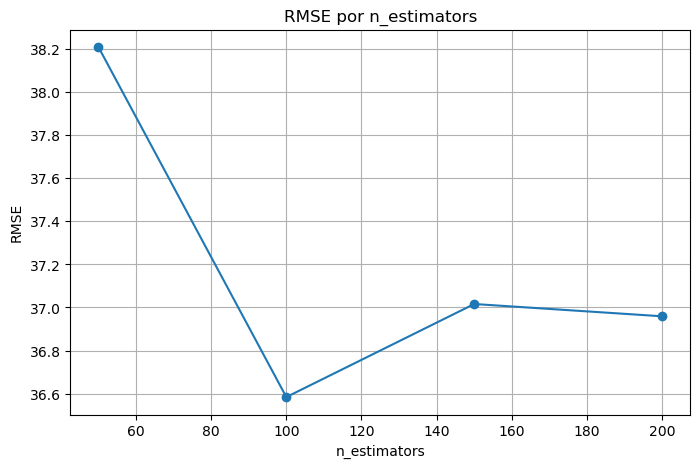

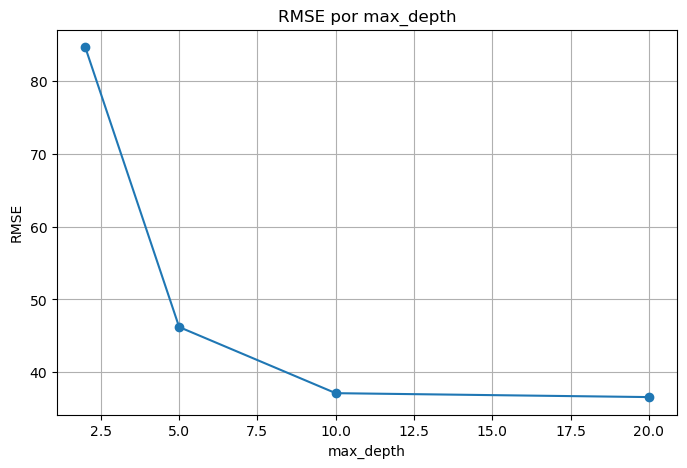

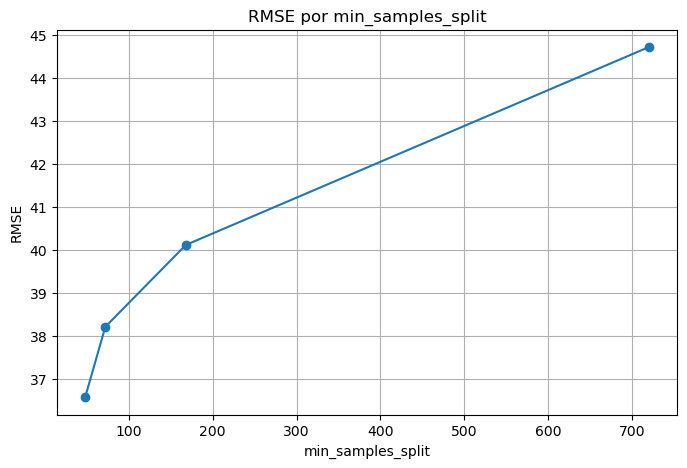

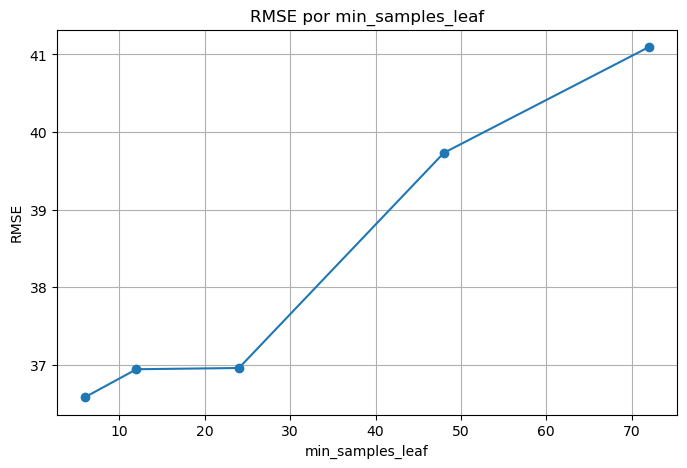

In [40]:
parameters = [
    'param_n_estimators',
    'param_max_depth',
    'param_min_samples_split',
    'param_min_samples_leaf'
]

for parameter in parameters:
    grouped_results = cv_results.groupby(parameter)['mean_test_score'].max().reset_index()
    grouped_results['RMSE'] = -grouped_results['mean_test_score']

    plt.figure(figsize=(8, 5))
    plt.plot(grouped_results[parameter], grouped_results['RMSE'], marker='o')
    plt.xlabel(parameter.replace('param_', ''))
    plt.ylabel('RMSE')
    plt.title(f'RMSE por {parameter.replace("param_", "")}')
    plt.grid(True)
    plt.show()

In [53]:
rf_grid = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=48,
    min_samples_leaf=6,
    random_state=SEED,
    n_jobs=6
)

df_result_grid = evaluate_train_validation(rf_grid, X)
df_result_grid

,Fold,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Train R2,Validation R2
0,1,23.103571,26.795509,38.403215,43.768196,0.955689,0.949372
1,2,23.155271,21.567768,38.516345,35.233829,0.955439,0.963237
2,3,23.164524,22.277822,38.527241,35.464919,0.955416,0.960794
3,4,23.172525,21.750478,38.552403,37.829470,0.955358,0.953991
4,5,23.154167,20.858750,38.510611,33.307236,0.955454,0.953195


In [54]:
df_result_grid.mean()

Fold                3.000000
Train MAE          23.150012
Validation MAE     22.650066
Train RMSE         38.501963
Validation RMSE    37.120730
Train R2            0.955471
Validation R2       0.956118
dtype: float64

## Comparação de estabilidade

Após a busca de hiperparâmetros utilizando Grid Search, foi observada uma maior estabilidade das métricas entre os folds. Apesar de uma ligeira redução no desempenho médio do modelo, essa alteração representa um trade-off válido, pois a nova configuração apresentou um comportamento mais equilibrado entre treinamento e validação, reduzindo os indícios de overfitting.

A maior estabilidade entre os folds também indica um comportamento mais consistente diante de diferentes períodos da série, contribuindo para uma melhor capacidade de generalização do modelo.

In [63]:
validation_metrics = ['Validation MAE', 'Validation RMSE', 'Validation R2']

comparison = pd.DataFrame({
    'Modelo base média': df_result[validation_metrics].mean(),
    'Modelo base STD': df_result[validation_metrics].std(),
    'Melhor hiperparâmetro média': df_result_grid[validation_metrics].mean(),
    'Melhor hiperparâmetro STD': df_result_grid[validation_metrics].std()
})

comparison

,Modelo base média,Modelo base STD,Melhor hiperparâmetro média,Melhor hiperparâmetro STD
Validation MAE,21.701652,3.011257,22.650066,2.372378
Validation RMSE,34.361528,5.636463,37.120730,4.047714
Validation R2,0.962094,0.009487,0.956118,0.005725
